# Banking Customer Churn Prediction

The purpose of this project is to develop a binary classification model to predict customer churn in the banking sector using the **Banking Customer Churn Prediction Dataset** from Kaggle.

**Customer churn**, or **customer attrition**, is the number of existing customers lost over a specified period of time. It provides companies with an understanding of customer loyalty and directs attention to areas that are causing customers to leave. It is often used as one of the key business metrics, as the cost of retaining existing customers tends to be lower than the cost of acquiring new ones.

## Exploratory Data Analysis (EDA)

In [1]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import kagglehub
import os

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.plotting import heatmap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix

In [2]:
path = kagglehub.dataset_download("saurabhbadole/bank-customer-churn-prediction-dataset")
file_path = os.path.join(path, "Churn_Modelling.csv")

df = pd.read_csv(file_path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


The code executed above and the dataset description on Kaggle provide us with following information regarding the features: 

* RowNumber (number assigned to each row), 

* CustomerId (an identifier for each customer),

* Surname (the customer's last name),

* CreditScore (the customer's credit score),

* Geography (the geographical location of the customer),

* Gender (the customer's gender),

* Age (the customer's age),

* Tenure (the number of years the customer has been with the bank),

* Balance (the customer's account balance),

* NumOfProducts (the number of bank products the customer has),

* HasCrCard (indicates whether the customer has a credit card), 

* IsActiveMember (indicates whether the customer is an active member),

* EstimatedSalary (the customer's estimated salary),

* **Exited** (indicates whether the customer has exited the bank) - target variable.

First, we are going to remove the columns: RowNumber, CustomerId and Surname, as they are used to identify the customer and will not be needed in the further analysis.

In [4]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


We are dealing with both numerical and categorical features. Let us display the categorical features and see their unique values.

In [5]:
cat_data = df.select_dtypes(include=['object', 'string']).columns.tolist()

for c in cat_data:
    print(f"Feature: {c}")
    print(f"Values: {df[c].unique().tolist()}")

Feature: Geography
Values: ['France', 'Spain', 'Germany']
Feature: Gender
Values: ['Female', 'Male']


The data comes from three countries: France, Spain and Germany. In the gender column we have two values: Female and Male.

We will now check the distribution of the target variable.

In [6]:
stayed, exited = df["Exited"].value_counts(normalize=True)

print(f"The percentage of customers that exited the bank: {exited*100:.2f}%.")
print(f"The percentage of customers that stayed with the bank: {stayed*100:.2f}%.")

The percentage of customers that exited the bank: 20.37%.
The percentage of customers that stayed with the bank: 79.63%.


We can see that the classes are unbalanced, as only about 20.37% of customers exited the bank. The imbalance may bias classification models - we are going to address the issue during modelling.

Let us now explore the pair-wise correlation between the numerical features using a heatmap.

In [7]:
num_data = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

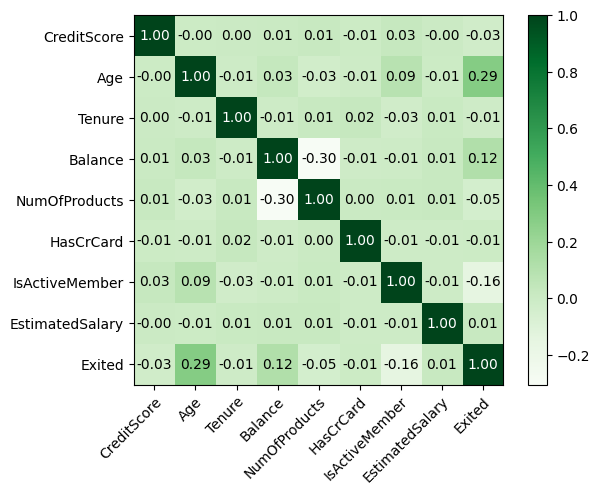

In [8]:
cm = np.corrcoef(df[num_data].values.T)
hm = heatmap(cm, row_names=num_data, column_names=num_data, cmap='Greens')

plt.show()

The analysis suggests that the numerical features and the target variable are generally weakly correlated. There is also no indication of multicollinearity between the features.

Let us now see the correlation between the categorical features and the target variable.

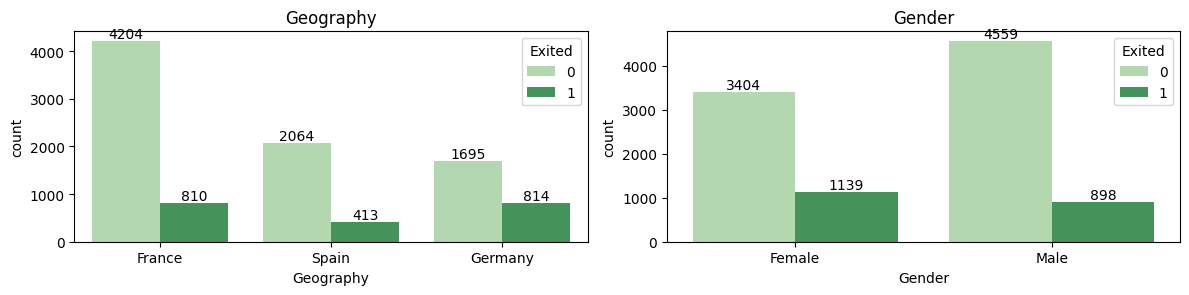

In [9]:
plt.figure(figsize=(12,8))
for i, c in enumerate(cat_data):
  plt.subplot(3,2,i+1)

  ax = sns.countplot(x=df[c], hue=df['Exited'], palette='Greens', legend=True)
  plt.title(c)
  for j in ax.containers:
    ax.bar_label(j)

plt.tight_layout()
plt.show()

As we can see from the plot related to the geographic location of the customer, the customers in Germany have the highest tendency to churn, with 814 out of 2509 customers having exited the bank. France and Spain both have significantly more customers than Germany, however their churn rates are lower.

The plot related to gender indicates that women have a higher likelihood of churning - the number of female customers who have exited the bank is 1139 (around 25% of all female customers), while for the male customers the number is significantly lower (898, which is around 16% of all male customers).

## Data preprocessing

In [10]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

There are no missing values. We will now use one-hot-encoding to convert nominal features into integers.

In [11]:
df = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True


Let us partition the dataset into the training set and the test set. We use stratified sampling (stratify=y) to preserve the class distribution of the target variable across both subsets. We also use standardization in order to bring all features onto the same scale.

In [12]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

## Models

We are going to train several models. For each model we will perform a grid search in order to identify the optimal hyperparameter values.

Because of the class imbalance in the dataset, during grid search we use the F1-score as the evaluation metric. The F1-score provides a balance between precision and recall, ensuring that both false positives and false negatives are taken into account.

In the final model evaluation, we are going to use Precision, Recall and ROC-AUC alongside the F1-score to provide a complete picture of the performance of every model.

In [13]:
results = []
confusion_matrices = {}

### Logistic Regression

In [14]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

lr_param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
     "model__class_weight": [None, "balanced"]
}

lr_gs = GridSearchCV(
    pipe,
    lr_param_grid,
    cv=5,
    refit=True,
    scoring="f1",
    n_jobs=-1
)

lr_gs.fit(X_train, y_train)

print(f"The best score: {lr_gs.best_score_:.5f}")
print(f"The best hyperparameter values: {lr_gs.best_params_}")

lr_y_pred = lr_gs.predict(X_test)
lr_y_pred_prob = lr_gs.predict_proba(X_test)[:,1]

results.append({
        "Model": "Logistic Regression",
        "F1": f1_score(y_test, lr_y_pred),
        "Precision": precision_score(y_test, lr_y_pred),
        "Recall": recall_score(y_test, lr_y_pred),
        "ROC-AUC": roc_auc_score(y_test, lr_y_pred_prob)
    })

confusion_matrices["Logistic Regression"] = confusion_matrix(y_test, lr_y_pred)

The best score: 0.49132
The best hyperparameter values: {'model__C': 10.0, 'model__class_weight': 'balanced'}


### Decision Tree

In [15]:
dt_param_grid = {
    "max_depth": [3, 5, 10, 20],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"]
}

dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    dt_param_grid,
    cv=5,
    refit=True,
    scoring="f1",
    n_jobs=-1
)

dt_gs.fit(X_train, y_train)

print(f"The best score: {dt_gs.best_score_:.5f}")
print(f"The best hyperparameter values: {dt_gs.best_params_}")

dt_y_pred = dt_gs.predict(X_test)
dt_y_pred_prob = dt_gs.predict_proba(X_test)[:,1]

results.append({
        "Model": "Decision Tree",
        "F1": f1_score(y_test, dt_y_pred),
        "Precision": precision_score(y_test, dt_y_pred),
        "Recall": recall_score(y_test, dt_y_pred),
        "ROC-AUC": roc_auc_score(y_test, dt_y_pred_prob)
    })

confusion_matrices["Decision Tree"] = confusion_matrix(y_test, dt_y_pred)

The best score: 0.56488
The best hyperparameter values: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5}


### Random Forest

In [16]:
rf_param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 5, 10, 20],
    "class_weight": [None, "balanced"]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=1),
    rf_param_grid,
    cv=5,
    refit=True,
    scoring="f1",
    n_jobs=-1
)

rf_gs.fit(X_train, y_train)

print(f"The best score: {rf_gs.best_score_:.5f}")
print(f"The best hyperparameter values: {rf_gs.best_params_}")

rf_y_pred = rf_gs.predict(X_test)
rf_y_pred_prob = rf_gs.predict_proba(X_test)[:,1]

results.append({
        "Model": "Random Forest",
        "F1": f1_score(y_test, rf_y_pred),
        "Precision": precision_score(y_test, rf_y_pred),
        "Recall": recall_score(y_test, rf_y_pred),
        "ROC-AUC": roc_auc_score(y_test, rf_y_pred_prob)
    })

confusion_matrices["Random Forest"] = confusion_matrix(y_test, rf_y_pred)

The best score: 0.62037
The best hyperparameter values: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}


Let us also check the feature importance.

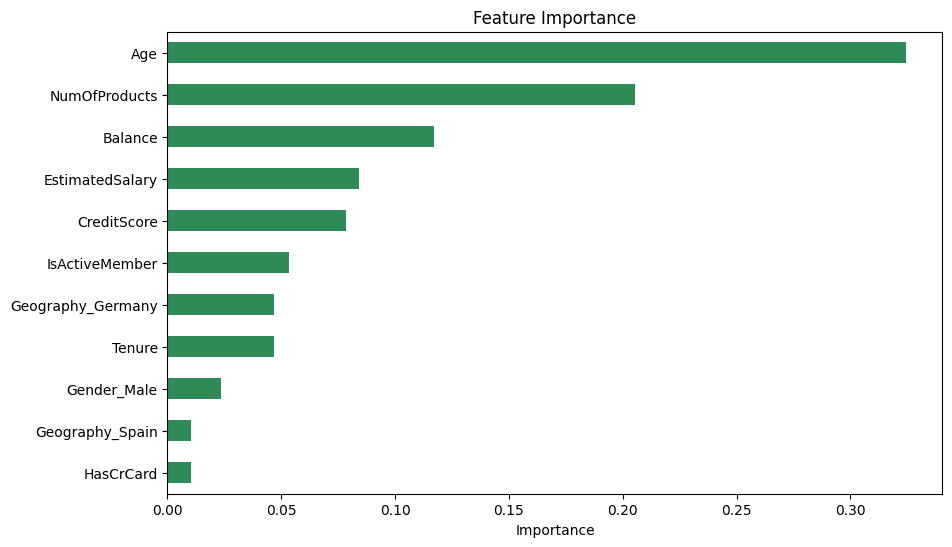

In [17]:
rf_model = rf_gs.best_estimator_
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind="barh", color='seagreen')
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

The most important features include the customer's age, the number of bank products they have, their account balance, estimated salary and credit score. Age is the top-ranked feature, however it is the only demographic factor out of the top five, with the remaining four relating to the customer's behaviour.

### XGBoost

In [18]:
xg_param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 5],
    "scale_pos_weight": [1, 4]
}

xg_gs = GridSearchCV(
    XGBClassifier(random_state=1, eval_metric="logloss"),
    xg_param_grid,
    cv=5,
    refit=True,
    scoring="f1",
    n_jobs=-1
)

xg_gs.fit(X_train, y_train)

print(f"The best score: {xg_gs.best_score_:.5f}")
print(f"The best hyperparameter values: {xg_gs.best_params_}")

xg_y_pred = xg_gs.predict(X_test)
xg_y_pred_prob = xg_gs.predict_proba(X_test)[:,1]

results.append({
        "Model": "XGBoost",
        "F1": f1_score(y_test, xg_y_pred),
        "Precision": precision_score(y_test, xg_y_pred),
        "Recall": recall_score(y_test, xg_y_pred),
        "ROC-AUC": roc_auc_score(y_test, xg_y_pred_prob)
    })

confusion_matrices["XGBoost"] = confusion_matrix(y_test, xg_y_pred)

The best score: 0.61046
The best hyperparameter values: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 4}


## Model Evaluation and Comparison

In the comparison below, we use the F1 score, Precision, Recall and ROC-AUC.

Precision (PRE) is computed using the formula

$$
\text{PRE} = \frac{\text{True Positives}}{\text{True Positives}+\text{False Positives}}.
$$

Precision reflects the correctness of positive predictions, i.e., how many customers predicted to churn actually churned.

Recall (REC) is synonymous with true positive rate (TPR):

$$
\text{REC} = \text{TPR} = \frac{\text{True Positives}}{\text{False Negatives} + \text{True Positives}}.
$$

It is especially useful for imbalanced class problems. Recall measures the proportion of customers who churned that were correctly identified by the model.

The F1 score is a combination of the precision and recall metrics

$$
\text{F1} = 2\;\frac{\text{Precision}\times\text{Recall}}{\text{Precision}+\text{Recall}},
$$

and it provides a balanced measure of performance.

Receiver Operating Characteristic Area Under the Curve (ROC-AUC) measures how well the model distinguishes between churners and non-churners across all possible thresholds. It is based on the False Positive Rate and the True Positive Rate.

In [19]:
results_df = pd.DataFrame(results).round(3)
results_df = results_df.sort_values(by="F1", ascending=False)
results_df

,Model,F1,Precision,Recall,ROC-AUC
2,Random Forest,0.595,0.571,0.622,0.856
3,XGBoost,0.577,0.505,0.673,0.848
1,Decision Tree,0.541,0.438,0.708,0.835
0,Logistic Regression,0.507,0.392,0.720,0.781


For **Logistic Regression** we achieve the highest recall score, however the lowest values for F1, ROC-AUC, and precision. Very low precision means that our model may predict many churners incorrectly.

For **Decision Tree** we achieve slightly better results than for Logistic Regression, but the method still remains inferior to the remaining models.

**XGBoost** achieves a high recall and ROC-AUC score. However, its lower precision compared to Random Forest suggests a higher rate of false positives.

For **Random Forest** we achieve the highest F1, precision and ROC-AUC scores. Recall score is the lowest of all models, but the value is still moderate. This model may predict fewer false positives, however it may also miss more churners.

Let us also see the confusion matrices for all models.

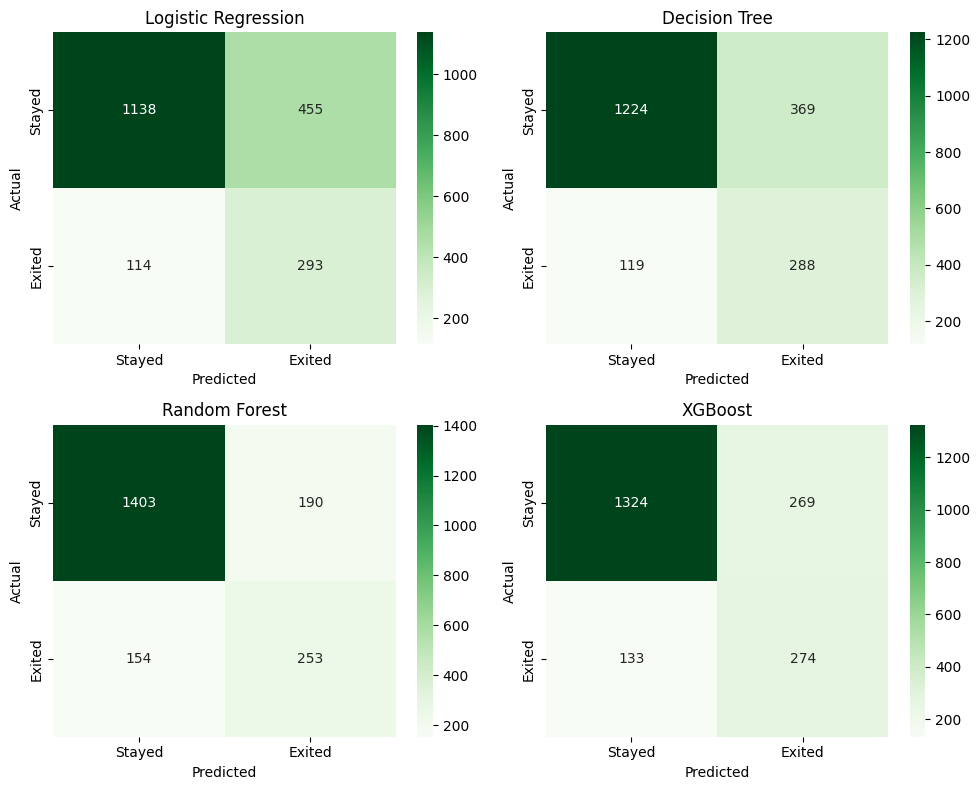

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))

for ax, (name, cm) in zip(axes.flatten(), confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, xticklabels=['Stayed', 'Exited'], yticklabels=['Stayed', 'Exited'])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Model Selection

Out of all models analyzed above, Random Forest provides the best overall results. Although its lower recall suggests that it may fail to identify some churned customers, it achieves the highest values for the F1 score, precision and ROC-AUC metrics, indicating the most reliable predictions.